In [51]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import numpy as np
from typing import List, Tuple, Dict, Any
from dataclasses import dataclass
from Scripts.detection import extract_regions_with_detector, load_detectors_config
from Scripts.configs import DetectorConfig, ScriptOptions
import os


def load_detector_from_config(config_path: str, detector_name: str = None) -> List[DetectorConfig]:
    """
    Загружает конфигурацию детекторов из файла
    
    Args:
        config_path (str): Путь к JSON файлу с конфигурацией
        detector_name (str, optional): Имя конкретного детектора для загрузки
        
    Returns:
        List[DetectorConfig]: Список конфигураций детекторов
    """
    if not os.path.exists(config_path):
        print(f"Файл конфигурации детекторов не найден: {config_path}")
        return []

    try:
        with open(config_path, 'r', encoding='utf-8') as f:
            config_data = json.load(f)
    except json.JSONDecodeError as e:
        print(f"Ошибка в формате конфигурационного файла: {e}")
        return []

    detectors = []
    for item in config_data:
        if detector_name and item["name"] != detector_name:
            continue
            
        try:
            detector = DetectorConfig(
                name=item["name"],
                model_path=item["model_path"],
                confidence=item.get("confidence", 0.25),
                classes=item.get("classes", [0]),
                remove_tags_from_full=item.get("remove_tags_from_full", []),
                remove_tags_from_region=item.get("remove_tags_from_region", []),
                add_tags_to_region=item.get("add_tags_to_region", {}),
                exclude_from_region=item.get("exclude_from_region", []),
                region_gen_threshold=item.get("region_gen_threshold"),
                region_char_threshold=item.get("region_char_threshold")
            )
            detectors.append(detector)
        except KeyError as e:
            print(f"Ошибка в конфигурации детектора: отсутствует обязательное поле {e}")
        except Exception as e:
            print(f"Ошибка обработки конфигурации детектора: {e}")

    return detectors

def extract_regions_with_detector(img_path: str, detector: DetectorConfig, yolo_model: YOLO) -> List[Tuple[Image.Image, List[float], List[float], str]]:
    """
    Использует YOLO для детектирования объектов и вырезает квадратные области в исходном разрешении.
    
    Args:
        img_path: Путь к изображению
        detector: Конфигурация детектора
        yolo_model: Загруженная модель YOLO
        
    Returns:
        List of tuples (cropped_image, square_bbox, original_bbox, detector_name)
    """
    # Загрузка изображения
    img = Image.open(img_path)
    img_width, img_height = img.size
    
    # Запускаем YOLO детекцию с параметрами из конфигурации детектора
    results = yolo_model(img_path, conf=detector.confidence, classes=detector.classes)
    
    # Извлекаем обнаруженные области
    regions = []
    
    # Проверяем, есть ли какие-либо результаты
    if len(results) > 0 and hasattr(results[0], 'boxes'):
        # Извлекаем боксы из результатов YOLO
        for result in results:
            boxes = result.boxes
            for box in boxes:
                # Получаем координаты бокса
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                
                # Преобразуем прямоугольник в квадрат, сохраняя центр обнаруженного объекта
                box_width = x2 - x1
                box_height = y2 - y1
                
                # Определяем размер квадрата по большей стороне
                square_size = max(box_width, box_height)
                
                # Вычисляем центр бокса
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2
                
                # Вычисляем новые координаты для квадратного бокса
                new_x1 = center_x - square_size / 2
                new_y1 = center_y - square_size / 2
                new_x2 = center_x + square_size / 2
                new_y2 = center_y + square_size / 2
                
                # Убеждаемся, что квадрат не выходит за границы изображения
                new_x1 = max(0, new_x1)
                new_y1 = max(0, new_y1)
                new_x2 = min(img_width, new_x2)
                new_y2 = min(img_height, new_y2)
                
                # Корректируем размер, если квадрат оказался за границами изображения
                current_width = new_x2 - new_x1
                current_height = new_y2 - new_y1
                
                # Если после обрезки по границе изображения получился не квадрат, 
                # подгоняем размер по минимальной стороне
                if current_width != current_height:
                    min_side = min(current_width, current_height)
                    
                    if current_width > min_side:
                        diff = current_width - min_side
                        new_x1 += diff / 2
                        new_x2 -= diff / 2
                    elif current_height > min_side:
                        diff = current_height - min_side
                        new_y1 += diff / 2
                        new_y2 -= diff / 2
                
                # Обрезаем изображение по новым координатам
                cropped_img = img.crop((int(new_x1), int(new_y1), int(new_x2), int(new_y2)))
                
                # Добавляем обрезанное изображение, координаты и имя детектора в список
                regions.append((
                    cropped_img, 
                    [new_x1, new_y1, new_x2, new_y2],  # квадратный бокс
                    [x1, y1, x2, y2],  # оригинальный бокс
                    detector.name
                ))
    
    return regions

def test_detector_visualization(image_path: str, detector_config: DetectorConfig, options: ScriptOptions = None):
    """
    Тестирует функцию extract_regions_with_detector и визуализирует результаты
    
    Args:
        image_path (str): Путь к изображению
        detector_config (DetectorConfig): Конфигурация детектора
        options (ScriptOptions, optional): Опции скрипта
    """
    # Определяем путь к модели
    if options and options.yolo_model_dir:
        model_path = Path(options.yolo_model_dir) / detector_config.model_path
    else:
        model_path = Path("./models/yolo") / detector_config.model_path
    
    # Загружаем модель YOLO
    try:
        model = YOLO(str(model_path))
        print(f"Модель {model_path} успешно загружена")
    except Exception as e:
        print(f"Ошибка загрузки модели {model_path}: {e}")
        return None
    
    print(f"Применяем детектор: {detector_config.name}")
    print(f"Порог уверенности: {detector_config.confidence}")
    print(f"Классы для обнаружения: {detector_config.classes}")
    
    # Загружаем изображение для проверки существования
    try:
        img = Image.open(image_path)
        print(f"Изображение {image_path} успешно загружено (размер: {img.size[0]}x{img.size[1]})")
    except Exception as e:
        print(f"Ошибка загрузки изображения {image_path}: {e}")
        return None
    
    # Получаем регионы
    regions = extract_regions_with_detector(image_path, detector_config, model)
    print(f"Обнаружено объектов: {len(regions)}")
    
    # Загружаем изображение для визуализации
    img_array = np.array(img)
    
    # Создаем фигуру для отображения
    n_regions = len(regions)
    if n_regions == 0:
        print("Не обнаружено ни одного объекта!")
        return None
    
    # Определим количество строк и столбцов для отображения всех регионов
    n_cols = min(3, n_regions)  # Максимум 3 столбца для регионов
    n_rows = (n_regions + n_cols - 1) // n_cols + 1  # +1 для исходного изображения
    
    fig = plt.figure(figsize=(15, 5 * n_rows))
    
    # Отображаем исходное изображение со всеми боксами
    ax_main = plt.subplot2grid((n_rows, n_cols), (0, 0), colspan=n_cols)
    ax_main.imshow(img_array)
    ax_main.set_title(f'Исходное изображение с объектами ({detector_config.name})')
    
    # Рисуем оригинальные боксы (прямоугольники) красным цветом
    for _, square_box, orig_box, _ in regions:
        rect = patches.Rectangle(
            (orig_box[0], orig_box[1]), 
            orig_box[2] - orig_box[0], 
            orig_box[3] - orig_box[1], 
            linewidth=2, 
            edgecolor='r', 
            facecolor='none',
            label='Оригинальный бокс'
        )
        ax_main.add_patch(rect)
        
        # Добавляем метки с размерами
        width = orig_box[2] - orig_box[0]
        height = orig_box[3] - orig_box[1]
        ax_main.text(
            orig_box[0], 
            orig_box[1] - 5, 
            f'Размер: {width:.1f}x{height:.1f}',
            color='red',
            fontsize=8
        )
    
    # Рисуем квадратные боксы синим цветом
    for _, square_box, _, _ in regions:
        rect = patches.Rectangle(
            (square_box[0], square_box[1]), 
            square_box[2] - square_box[0], 
            square_box[3] - square_box[1], 
            linewidth=2, 
            edgecolor='b', 
            facecolor='none',
            label='Квадратный бокс'
        )
        ax_main.add_patch(rect)
        
        # Добавляем метки с размерами
        width = square_box[2] - square_box[0]
        height = square_box[3] - square_box[1]
        ax_main.text(
            square_box[0], 
            square_box[3] + 15, 
            f'Размер: {width:.1f}x{height:.1f}',
            color='blue',
            fontsize=8
        )
    
    # Добавляем легенду
    handles = [
        patches.Patch(edgecolor='r', facecolor='none', label='Оригинальный бокс'),
        patches.Patch(edgecolor='b', facecolor='none', label='Квадратный бокс')
    ]
    ax_main.legend(handles=handles, loc='upper right')
    
    ax_main.set_axis_off()
    
    # Отображаем каждый вырезанный регион
    for i, (region_img, square_box, orig_box, _) in enumerate(regions):
        # Корректный способ расчета строки и столбца
        row = 1 + (i // n_cols)  # +1 потому что первая строка занята исходным изображением
        col = i % n_cols
        
        ax_region = plt.subplot2grid((n_rows, n_cols), (row, col))
        ax_region.imshow(np.array(region_img))
        
        # Размеры оригинального и квадратного бокса
        orig_width = orig_box[2] - orig_box[0]
        orig_height = orig_box[3] - orig_box[1]
        square_width = square_box[2] - square_box[0]
        square_height = square_box[3] - square_box[1]
        
        # Отношение сторон для оригинального бокса
        aspect_ratio = orig_width / orig_height if orig_height > 0 else 0
        
        ax_region.set_title(
            f'Регион {i+1}\n'
            f'Ориг: {orig_width:.1f}x{orig_height:.1f} (AR: {aspect_ratio:.2f})\n'
            f'Квадрат: {square_width:.1f}x{square_height:.1f}'
        )
        ax_region.set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    return regions


def main_test(image_path: str, config_path: str, detector_name: str = None):
    """
    Основная функция для тестирования.
    
    Args:
        image_path (str): Путь к изображению
        config_path (str): Путь к конфигурационному файлу
        detector_name (str, optional): Имя конкретного детектора
    """
    # Загружаем настройки скрипта (можно создать дефолтные)
    options = ScriptOptions(
        ImageFolder=Path("."),
        yolo_model_dir=Path("./models/yolo/")
    )
    
    # Загружаем детекторы из конфига
    detectors = load_detector_from_config(config_path, detector_name)
    
    if not detectors:
        if detector_name:
            print(f"Детектор '{detector_name}' не найден в конфигурации")
        else:
            print("Не найдено ни одного детектора в конфигурации")
        return
    
    # Тестируем каждый детектор
    for detector in detectors:
        print(f"\n--- Тестирование детектора '{detector.name}' ---")
        test_detector_visualization(image_path, detector, options)

# Пример использования:
# image_path = "path/to/your/image.jpg"
# detector_config = DetectorConfig(
#     name="person_detector",
#     model_path="yolov8n.pt",
#     confidence=0.25,
#     classes=[0]  # класс 0 в COCO - это "person"
# )
# test_detector_visualization(image_path, detector_config, "yolov8n.pt")


--- Тестирование детектора 'person_detector' ---
Модель models\yolo\person_yolov8s-seg.pt успешно загружена
Применяем детектор: person_detector
Порог уверенности: 0.4
Классы для обнаружения: [0]
Изображение C:/Users/liali/YoloWdTagger/wdv3-timm/Tests/abc/GdjyZ8t.png успешно загружено (размер: 1920x1080)

image 1/1 C:\Users\liali\YoloWdTagger\wdv3-timm\Tests\abc\GdjyZ8t.png: 384x640 2 persons, 97.6ms
Speed: 5.3ms preprocess, 97.6ms inference, 15.4ms postprocess per image at shape (1, 3, 384, 640)
Обнаружено объектов: 2


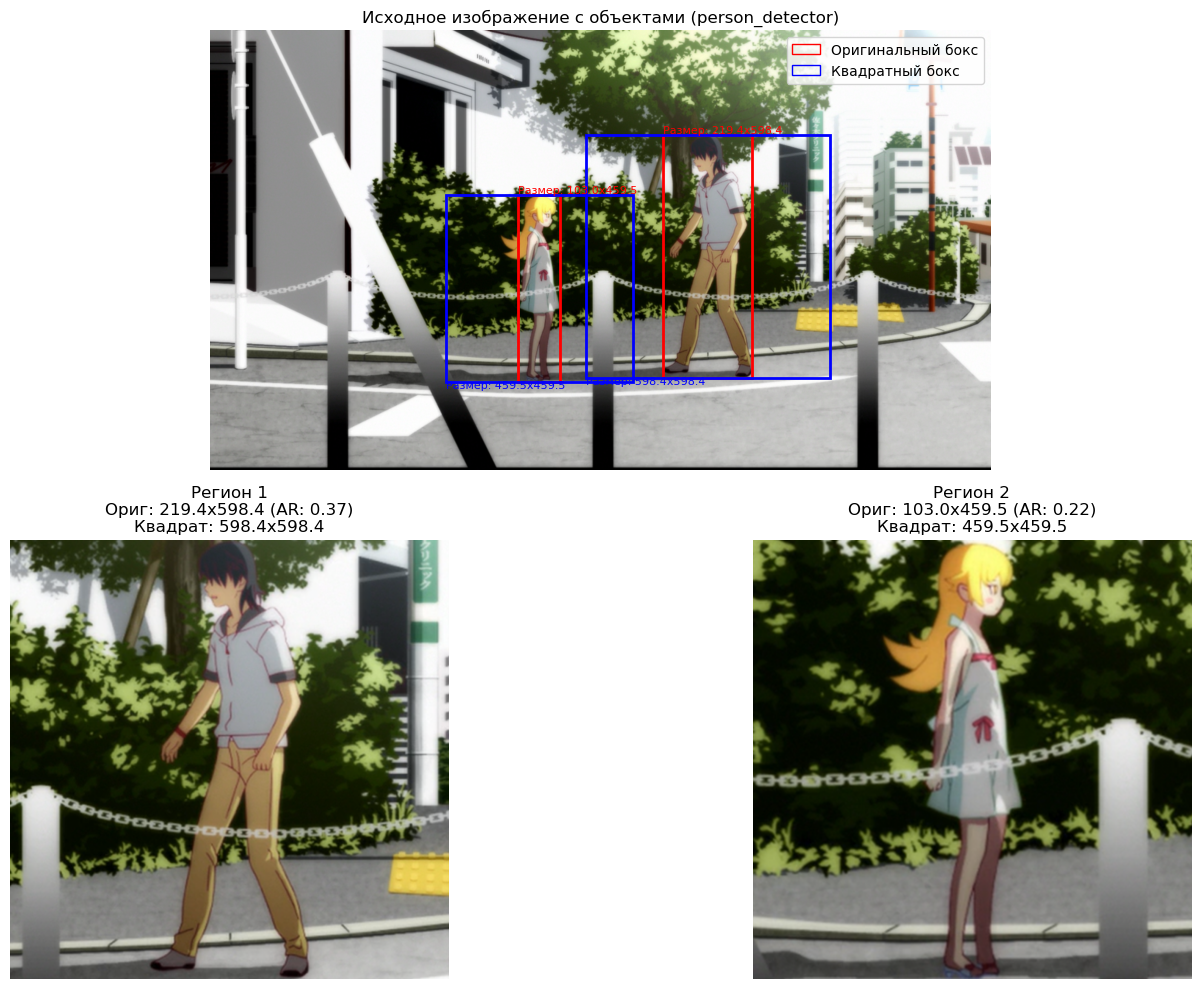


--- Тестирование детектора 'face_detector' ---
Модель models\yolo\face_yolov9c.pt успешно загружена
Применяем детектор: face_detector
Порог уверенности: 0.4
Классы для обнаружения: [0]
Изображение C:/Users/liali/YoloWdTagger/wdv3-timm/Tests/abc/GdjyZ8t.png успешно загружено (размер: 1920x1080)

image 1/1 C:\Users\liali\YoloWdTagger\wdv3-timm\Tests\abc\GdjyZ8t.png: 384x640 2 faces, 92.4ms
Speed: 2.8ms preprocess, 92.4ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)
Обнаружено объектов: 2


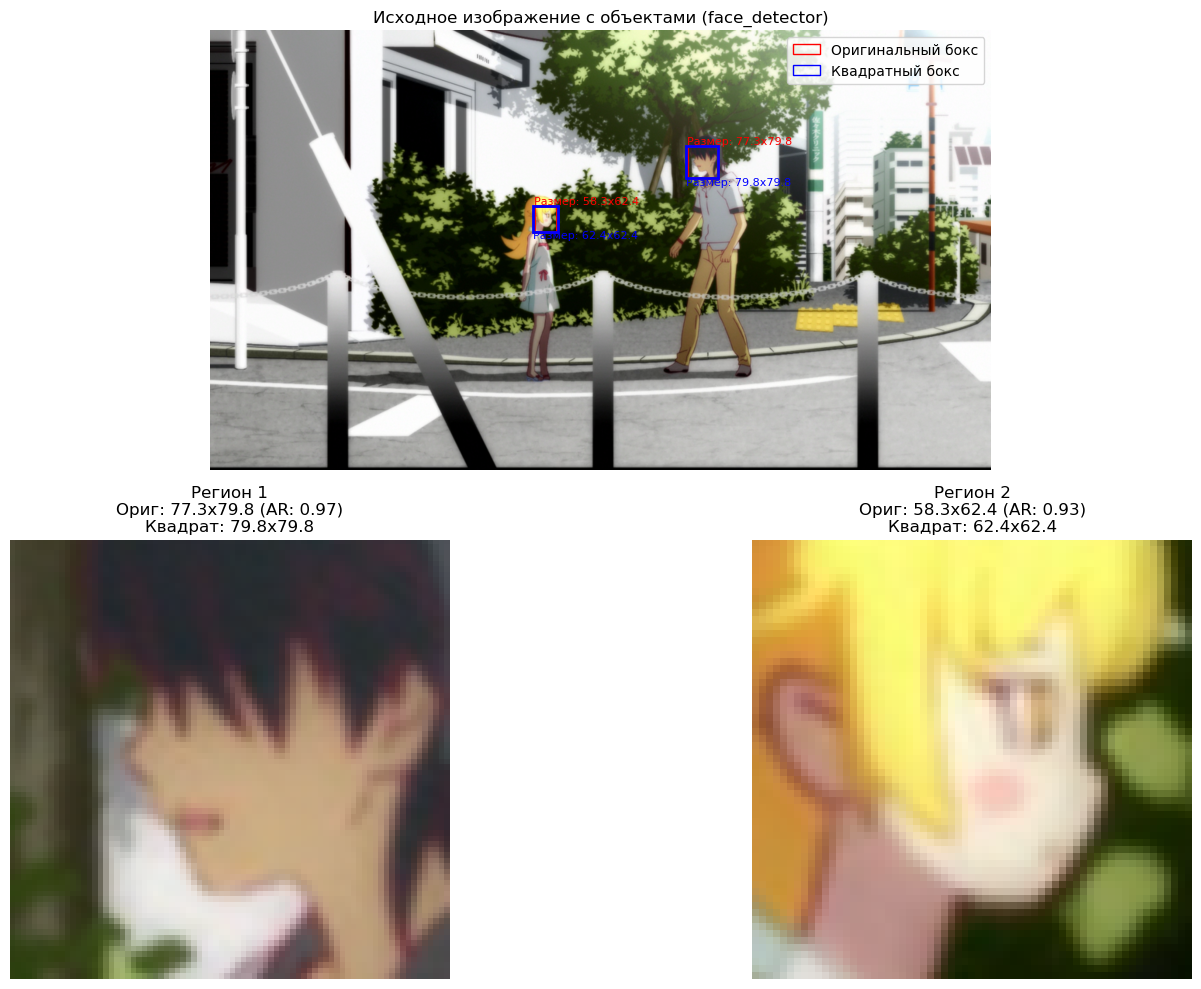

In [61]:


image_path = r"C:/Users/liali/YoloWdTagger/wdv3-timm/Tests/abc/GdjyZ8t.png"
config_path= r"detectors.json"

 

    
main_test(image_path, config_path, None)